In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from helpers_takarada import * 
import seaborn as sns
def colorFader(c1, c2, mix=0.5):
    c1 = np.array(matplotlib.colors.to_rgb(c1))
    c2 = np.array(matplotlib.colors.to_rgb(c2))
    return matplotlib.colors.to_hex((1-mix)*c1 + mix*c2)
from module_takarada import * 
parameters1 = {'n_pass' : 1e-4,
'epsilon_threshold' : 1e-10,
'N_epsilon' : 5,
'maxiter' : 500,
'eps_last' : 1e-10,
'dmu' : 5.,
'mix2' : 0.001,
'mix3' : 1.5,
'faktor1' : 0.1,
'max_trials' : 15,
'eps0' : 0.03,
}

parameters2 = {'n_pass' : 1e-4,
'epsilon_threshold' : 1e-10,
'N_epsilon' : 5,
'maxiter' : 500,
'eps_last' : 1e-10,
'dmu' : 5.,
'mix2' : 0.001,
'mix3' : 1.5,
'faktor1' : 0.1,
'max_trials' : 15,
'eps0' : 0.03,
}


---------
0.3582816364962562 (-0.20685325001744292+0j) (-0+0j)


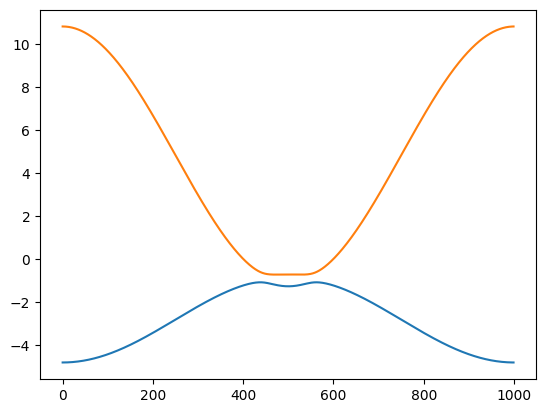

In [2]:
a = 1.
b = 0.5#5

t12 = 0.
delta = 0.

t = 1.
t_ = 3.
Vc = 0.
Vb = 2.
epsilon = 3.
epsilon_ = 3.

#epsilon = 0.5*(gap + 2*t_ + 2*t)
#epsilon_ = epsilon
#gap0 = epsilon_ - 2*t_ - (epsilon - 2*t)

phys_parameters = [b, t, t_, t12, epsilon, epsilon_, Vb, Vc, delta]

mu0 = 0.
include_hartree = True


Nk = 1000
print('---------')
m = model(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree)
m.GS()
m.mu = 0.5 * (np.min(m.energije[1]) + np.max(m.energije[0]))
gap = np.min(m.energije[1]) - np.max(m.energije[0])
print(gap, m.delta_b,  m.delta_c)

plt.plot(m.energije[0])
plt.plot(m.energije[1])


In [ ]:

t0 = 2.
sigma = 0.02
dt = 0.005
Omega = 0.
A0 = 0.01


tok = j_tok(m.K, phys_parameters, m.mu)
rhos, thetas = rho_operators(m.K, phys_parameters, include_hartree)

perturbation_operator = tok
measure_operators = tok

t_maxs = [50, 150, 300, 450]
meas = []
times = []
for i, t_max in enumerate(t_maxs):
    time, measurements = simulate_pulz(m.K, m.rho, phys_parameters, include_hartree, perturbation_operator, measure_operators, A0, t0, sigma, Omega, dt, t_max)
    measurements = measurements[:,0].real
    meas.append(measurements)
    times.append(time)

0.0
0.0005555555555555556
0.0011111111111111111
0.0016666666666666668
0.0022222222222222222
0.002777777777777778
0.0033333333333333335
0.0038888888888888888
0.0044444444444444444
0.005
0.005555555555555556
0.006111111111111111
0.006666666666666667
0.007222222222222222
0.0077777777777777776
0.008333333333333333
0.008888888888888889
0.009444444444444445
0.01
0.010555555555555556
0.011111111111111112
0.011666666666666667
0.012222222222222223
0.012777777777777779
0.013333333333333334
0.013888888888888888
0.014444444444444444
0.015
0.015555555555555555
0.01611111111111111
0.016666666666666666
0.017222222222222222
0.017777777777777778
0.018333333333333333
0.01888888888888889
0.019444444444444445
0.02
0.020555555555555556
0.021111111111111112
0.021666666666666667
0.022222222222222223
0.02277777777777778
0.023333333333333334
0.02388888888888889
0.024444444444444446
0.025
0.025555555555555557
0.026111111111111113
0.02666666666666667
0.02722222222222222
0.027777777777777776
0.028333333333333332


In [4]:
measurements = measurements[:,0].real

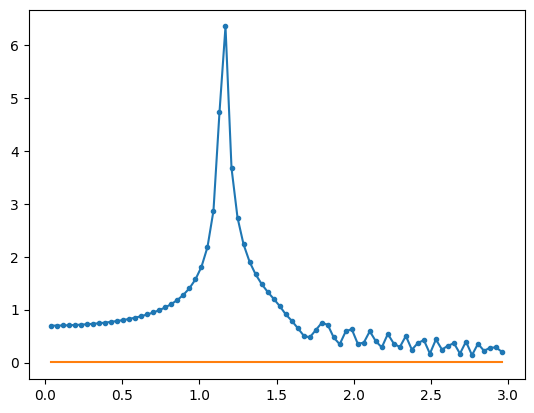

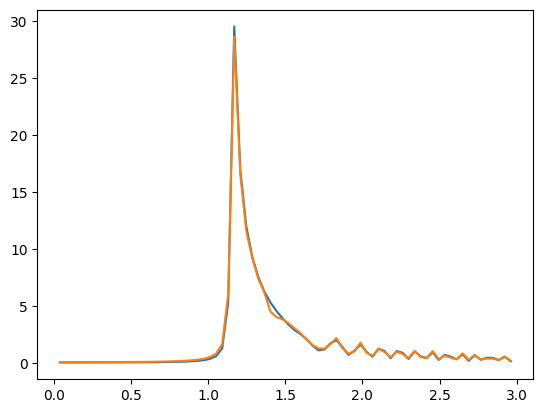

In [8]:
Gamma = 1 / t_max
sigma = 0.02


gap = np.min(m.energije[1]) - np.max(m.energije[0])
window = np.exp(- 2 * Gamma * time)

signal = np.fft.fft((measurements - measurements[0]) * window * dt)
probe = np.fft.fft(A_pulz(time, A0, t0, sigma, Omega) * window * dt)

omega  = 2*np.pi*np.fft.fftfreq(len(time), d=dt)

pos = (omega > 0) * (omega/gap < 3)
omega = omega[pos]
signal = signal[pos]
probe = probe[pos]

sigma = signal / (- 1j * omega * probe) / m.Nk
plt.plot(omega/gap, np.abs(signal), '.-')
plt.plot(omega/gap, np.abs(probe))
plt.show()
plt.plot(omega/gap, sigma.real)

chijj, dchi_jj, chi_rho_rho, chi_rho_j = chi_j_j(m.K, tok, rhos, thetas, m.vecs, m.energije, m.fs, omega, Gamma)
plt.plot(omega/gap, -chijj.imag / omega * 2)

0 0 0
0 0 1
1 0 0
1 0 1
2 0 0
2 0 1
3 0 0
3 0 1
0 1 0
0 1 1
1 1 0
1 1 1
2 1 0
2 1 1
3 1 0
3 1 1
0 2 0
0 2 1
1 2 0
1 2 1
2 2 0
2 2 1
3 2 0
3 2 1
0 3 0
0 3 1
1 3 0
1 3 1
2 3 0
2 3 1
3 3 0
3 3 1
0 4 0
0 4 1
1 4 0
1 4 1
2 4 0
2 4 1
3 4 0
3 4 1
0 5 0
0 5 1
1 5 0
1 5 1
2 5 0
2 5 1
3 5 0
3 5 1


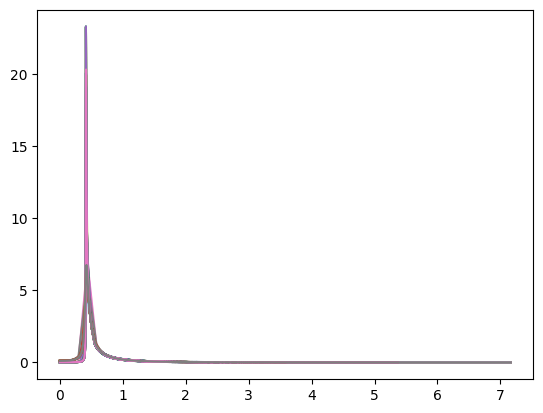

In [240]:
tok = j_tok(m.K, phys_parameters, m.mu)
tok_tilde = np.einsum('jix, jlx,lmx -> imx', m.vecs.conj(), tok, m.vecs)
Nomegas = [50, 100, 200, 500, 1000, 2000]
Gammas =  [1e-3, 1e-2]
ends = [5 * gap, 10 * gap, 15 * gap, 20 * gap]
suma = 0.
for n in range(m.Nk):
    for a in range(2):
        for b in range(2):
            if a != b:
                suma += -np.abs(tok_tilde[a,b,n])**2 * (m.fs[b,b,n] - m.fs[a,a,n]) / (m.energije[b,n] - m.energije[a,n]) 
suma = suma / m.Nk

lhs = np.zeros((len(ends), len(Nomegas), len(Gammas)))

for j, Nomega in enumerate(Nomegas):
    for nn in range(len(ends)):
        omega = np.linspace(0.001, ends[nn], Nomega)
        for i, Gamma in enumerate(Gammas):
            print(nn, j,i)
            jj, djj, chi_rh_rh, chi_rh_j = chi_j_j(m.K, phys_parameters, m.vecs, m.energije, m.fs, omega, Gamma, include_hartree)
            sigma_ = -jj.imag / omega
            plt.plot(omega, sigma_)

            lhs[nn, j,i] = 2/np.pi * np.trapz(sigma_.real, omega)
            #print(suma, lhs[j,i])

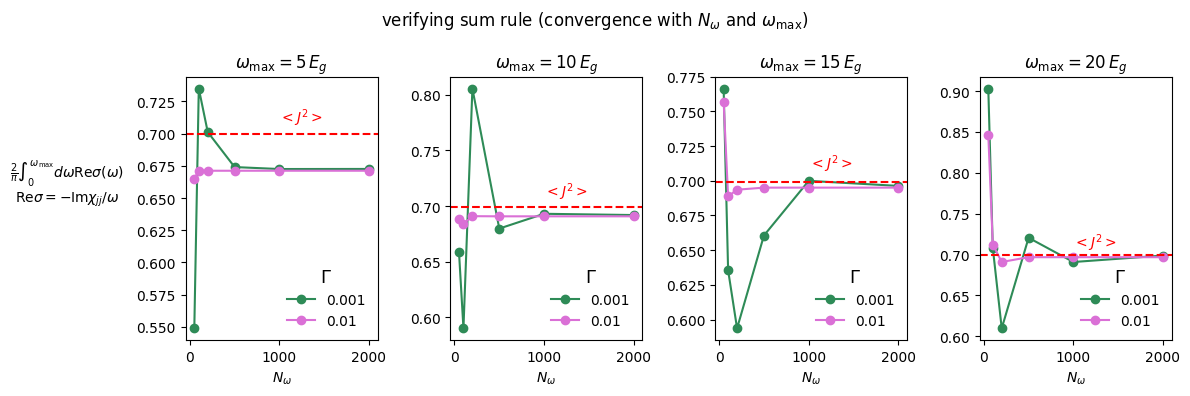

In [291]:
fig, ax = plt.subplots(ncols=len(ends), figsize=(len(ends) * 3, 4))
cols = ['seagreen', 'orchid']
for nn in range(len(ends)):
    for i, Gamma in enumerate(Gammas):
        ax[nn].plot(Nomegas, lhs[nn, :,i], 'o-', label=rf'{np.round(Gamma, 5)}', color=cols[i])
    ax[nn].axhline(suma, color='red', ls='dashed')
    ax[nn].legend(frameon=False, loc='lower right').set_title(r'$\Gamma$', prop={'size': 13})
    ax[nn].set_title(r'$\omega_{\text{max}}=$' + rf'${int(ends[nn]/gap)}\, E_g$')
    ax[nn].text(1000, suma + 0.01, r'$<J^2>$', color='red')
    ax[nn].set_xlabel(r'$N_{\omega}$')
ax[0].set_ylabel(r'$\frac{2}{\pi}\int_0^{\omega_{\text{max}}} d \omega \text{Re}\sigma(\omega)$' + '\n' + r'$\text{Re}\sigma = -\text{Im} \chi_{jj} / \omega$', rotation=0, labelpad=50)


fig.suptitle(r'verifying sum rule (convergence with $N_\omega$ and $\omega_{\text{max}}$)')

plt.tight_layout()
plt.savefig('sum-rule.pdf')

In [10]:
Gamma = 0.0003
sigma = 0.02

gap = np.min(m.energije[1]) - np.max(m.energije[0])
window = np.exp(- 2 * Gamma * rez[0])

signal = np.fft.fft((rez[1] - rez[1][0]) * window * dt)
probe = np.fft.fft(A_pulz(rez[0], A0, t0, sigma, Omega) * window * dt)

omega  = 2*np.pi*np.fft.fftfreq(len(rez[0]), d=dt)

pos = (omega > 0) * (omega/gap < 3)
omega = omega[pos]
signal = signal[pos]
probe = probe[pos]

sigma = signal / (1j * omega * probe) / m.Nk
plt.plot(omega/gap, np.abs(signal), '.-')
plt.plot(omega/gap, np.abs(probe))

plt.xlim(0,3)
plt.axvline(1., ls='dashed')

plt.xlim(0,3)

fs = np.zeros((2, 2, m.Nk))
T = gap/10
fs[0,0,:] = 1/(1 + np.exp((m.energije[0] - m.mu)/T))
fs[1,1,:] = 1/(1 + np.exp((m.energije[1] - m.mu)/T))

chi, chiR = chi_rho_rho(m.K, phys_parameters, m.vecs, m.energije, fs, omega, Gamma, include_hartree)
jj, djj, chi_rh_rh, chi_rh_j = chi_j_j(m.K, phys_parameters, m.vecs, m.energije, fs, omega, Gamma, include_hartree)

dHk2_dk2 = np.zeros((2, 2, m.Nk), dtype=np.complex128)
b, t, t_, t12, epsilon, epsilon_, Vb, Vc, delta = phys_parameters
dHk2_dk2[0,0,:] = -2*t*np.cos(m.K)
dHk2_dk2[1,1,:] = 2*t_*np.cos(m.K)
D = 0.
for n in range(m.Nk):
    D += np.trace(m.rho[:,:,n] @ dHk2_dk2[:,:,n])
D = D / m.Nk

sigma = signal / (1j * omega * probe) / m.Nk
sigma_ = -jj.imag / omega

np.sum(sigma_) * (omega[1] - omega[0]), np.sum(sigma) * (omega[1] - omega[0]) , D * np.pi / 2

tok = j_tok(m.K, phys_parameters, m.mu)
tok_tilde = np.einsum('jix, jlx,lmx -> imx', m.vecs.conj(), tok, m.vecs)

suma = 0.
for n in range(m.Nk):
    for a in range(2):
        for b in range(2):
            if a != b:
                suma += -np.abs(tok_tilde[a,b,n])**2 * (m.fs[b,b,n] - m.fs[a,a,n]) / (m.energije[b,n] - m.energije[a,n]) 
suma = suma / m.Nk

suma, np.sum(sigma_) * (omega[1] - omega[0]) * 2 / np.pi


MemoryError: Unable to allocate 149. GiB for an array with shape (100000, 100000) and data type complex128

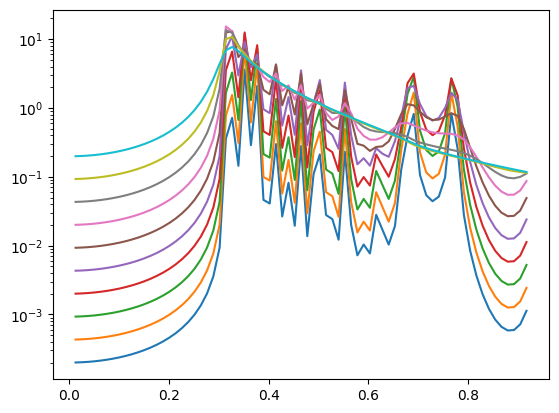

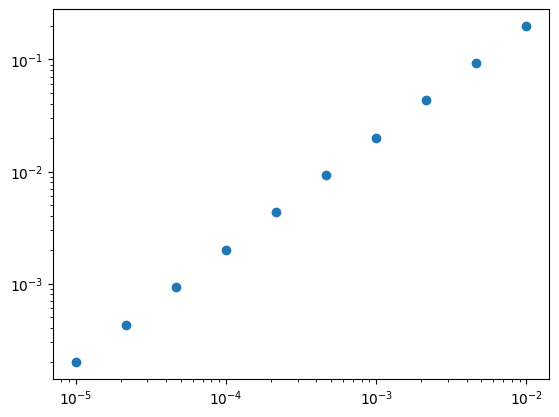

In [25]:
Gammas = np.logspace(-5,-2,10)
nulte = []
for i, Gamma in enumerate(Gammas):
    jj, djj, chi_rh_rh, chi_rh_j = chi_j_j(m.K, phys_parameters, m.vecs, m.energije, m.fs, omega, Gamma, include_hartree)
    plt.plot(omega, -jj.imag/omega)
    nulte.append(-jj.imag[0]/omega[0])
plt.yscale('log')
plt.show()
plt.scatter(Gammas, nulte)
plt.xscale('log')
plt.yscale('log')

ValueError: x and y must have same first dimension, but have shapes (2000,) and (85,)

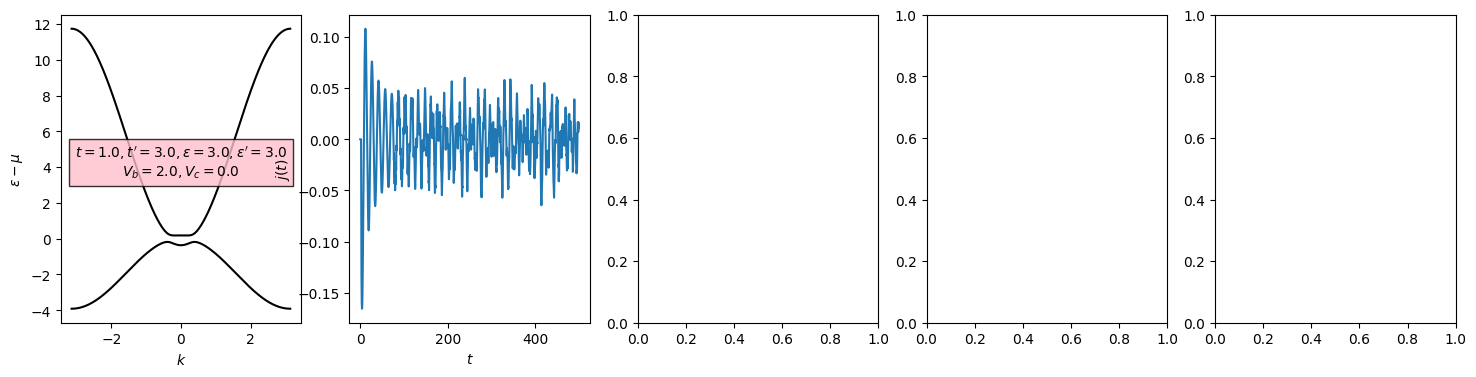

In [ ]:
fig, ax = plt.subplots(ncols=5, figsize=(18,4))
ax[0].plot(m.K, m.energije[1] - m.mu, color='0')
ax[0].plot(m.K, m.energije[0] - m.mu, color='0')
ax[0].set_xlabel(r'$k$')
ax[0].set_ylabel(r'$\epsilon - \mu$')
ax[0].text(0,3.5,rf"$t={t}, t'={t_}, \varepsilon={epsilon}, \varepsilon'={epsilon_}$" + "\n" + rf"$V_b={Vb}, V_c={Vc}$", ha='center',bbox=dict(facecolor='pink', alpha=0.8))

ax[1].plot(rez[0], rez[1].real - rez[1][0].real)
ax[1].set_xlabel(r'$t$')
ax[1].set_ylabel(r'$j(t)$')

ax[2].plot(omega/gap, np.abs(signal), '.-')
ax[2].plot(omega/gap, np.abs(probe) * 1000, label='FT[$A(t)$]')
ax[2].legend()
ax[2].set_xlabel(r'$\omega/E_g$')
ax[2].set_ylabel(r'FT[$j(t)$]')

sigma = signal / (1j * omega * probe) / m.Nk

ax[3].plot(omega/gap, sigma.real, lw=3, label=r'$\text{Re} \frac{j(\omega)}{i \omega A(\omega)}$')
ax[3].plot(omega/gap, -jj.imag / omega, label=r'$\text{Im} \chi_{jj}(\omega) / \omega$')
ax[3].plot(omega/gap, -jj.imag / omega * 2, color='red', ls='dashed', label=r'$2\times\text{Im} \chi_{jj}(\omega) / \omega$')
ax[3].set_xlabel(r'$\omega/E_g$')
ax[3].set_ylabel(r'$\sigma(\omega)$')
ax[3].legend(fontsize=10)#bbox_to_anchor=(0.3,1.1))

ax[4].plot(omega/gap, sigma.real, lw=3, label=r'$\text{Re} \frac{j(\omega)}{i \omega A(\omega)}$')
ax[4].plot(omega/gap, -jj.imag / omega, label=r'$\text{Im} \chi_{jj}(\omega) / \omega$')
ax[4].plot(omega/gap, -jj.imag / omega * 2, color='red', ls='dashed', label=r'$2\times\text{Im} \chi_{jj}(\omega) / \omega$')
ax[4].set_xlabel(r'$\omega/E_g$')
ax[4].set_ylabel(r'$\sigma(\omega)$')
ax[4].set_ylim(0,0.2)

plt.tight_layout()

(0.07491066028912531, 0.07453153722155728)

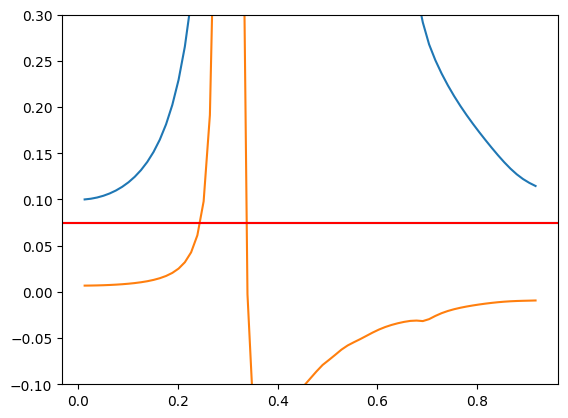

In [91]:
Gamma = 0.005
jj, djj, chi_rh_rh, chi_rh_j = chi_j_j(m.K, phys_parameters, m.vecs, m.energije, m.fs, omega, Gamma, include_hartree)

tok = j_tok(m.K, phys_parameters, m.mu)
tok2 = np.zeros(tok.shape, dtype=np.complex128)
delta_b, delta_c = Delta(m.K, m.rho, Vb, Vc)
tok2[0,1,:] = delta_c * (-1j) * (0 + 1 - b) * np.exp(-1j*m.K)
tok2[1,0,:] = tok2[0,1,:].conj()
tok_tilde = np.einsum('jix, jlx,lmx -> imx', m.vecs.conj(), tok, m.vecs)
tok_tilde2 = np.einsum('jix, jlx,lmx -> imx', m.vecs.conj(), tok2, m.vecs)
omegas = np.linspace(-0.5,0.5,501)
A = Spektralka(omegas, m.mu, m.energije, Gamma)
phi = phi_Kubo(m.K, tok_tilde, tok_tilde, A, omegas)
phi2 = phi_Kubo(m.K, tok_tilde2 + tok_tilde, tok_tilde + tok_tilde2, A, omegas)
sigma1 = np.sum(phi * (-fd_1(omegas, T))).real * (omegas[1] - omegas[0])
sigma2 = np.sum(phi2 * (-fd_1(omegas, T))).real * (omegas[1] - omegas[0])

plt.plot(omega, -jj.imag / omega)
plt.plot(omega, -djj.imag / omega)

plt.axhline(sigma1)
plt.axhline(sigma2, color='red')

plt.ylim(-0.1,0.3)
sigma1, sigma2

In [100]:

dHk2_dk2 = np.zeros((2, 2, m.Nk), dtype=np.complex128)
b, t, t_, t12, epsilon, epsilon_, Vb, Vc, delta = phys_parameters
dHk2_dk2[0,0,:] = -2*t*np.cos(m.K)
dHk2_dk2[1,1,:] = 2*t_*np.cos(m.K)
delta_b, delta_c = Delta(m.K, m.rho, Vb, Vc)
dHk2_dk2[0,1,:] += - delta_c * np.exp(-1j*m.K)
dHk2_dk2[1,0,:] += - delta_c * np.exp(-1j*m.K)
D = 0.
for n in range(m.Nk):
    D += np.trace(m.rho[:,:,n] @ dHk2_dk2[:,:,n])
D = D / m.Nk

sigma = signal / (1j * omega * probe) / m.Nk


np.sum(sigma.real) * (omega[1] - omega[0]), D * np.pi

(2.128768662494285, (2.2937143728106157+6.962635846085523e-19j))

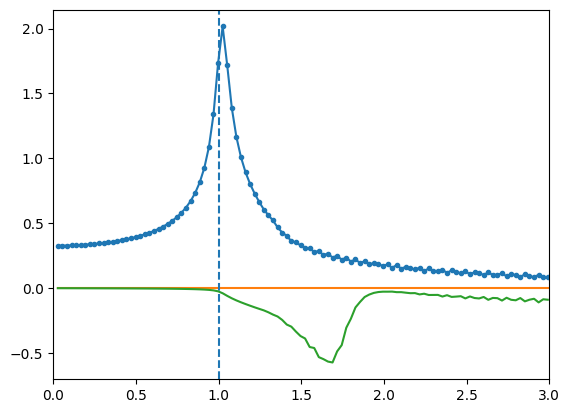

In [564]:
Gamma = 0.01
sigma = 0.02

gap = np.min(m.energije[1]) - np.max(m.energije[0])
window = np.exp(- 2 * Gamma * rez[0])

signal = np.fft.fft((rez[1] - rez[1][0]) * window * dt)
probe = np.fft.fft(A_pulz(rez[0], A0, t0, sigma, Omega) * window * dt)

omega  = 2*np.pi*np.fft.fftfreq(len(rez[0]), d=dt)

pos = (omega > 0) * (omega/gap < 3)
omega = omega[pos]
signal = signal[pos]
probe = probe[pos]

sigma = signal / (1j * omega * probe)
plt.plot(omega/gap, np.abs(signal), '.-')
plt.plot(omega/gap, np.abs(probe))

plt.xlim(0,3)
plt.axvline(1., ls='dashed')

plt.xlim(0,3)

chi, chiR = chi_rho_rho(m.K, phys_parameters, m.vecs, m.energije, m.fs, omega, Gamma, include_hartree)
jj, djj, chi_rh_rh, chi_rh_j = chi_j_j(m.K, phys_parameters, m.vecs, m.energije, m.fs, omega, Gamma, include_hartree)
plt.plot(omega/gap, chiR[1,1].imag)

ValueError: operands could not be broadcast together with shapes (51,) (22,) 

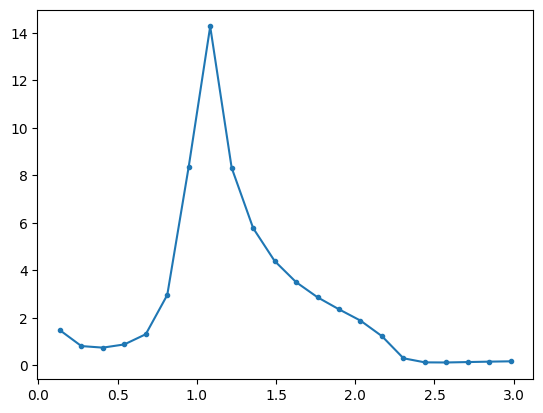

In [480]:
dHk2_dk2 = np.zeros((2, 2, m.Nk), dtype=np.complex128)
b, t, t_, t12, epsilon, epsilon_, Vb, Vc, delta = phys_parameters
dHk2_dk2[0,0,:] = -2*t*np.cos(m.K)
dHk2_dk2[1,1,:] = 2*t_*np.cos(m.K)
delta_b, delta_c = Delta(m.K, m.rho, Vb, Vc)
dHk2_dk2[0,1,:] += - delta_c * np.exp(-1j*m.K)
dHk2_dk2[1,0,:] += - delta_c * np.exp(-1j*m.K)
D = 0.
for n in range(m.Nk):
    D += np.trace(m.rho[:,:,n] @ dHk2_dk2[:,:,n])
D = D / m.Nk

plt.plot(omega/gap, sigma.real / m.Nk / 2, '.-')
plt.plot(omega/gap, -jj.imag  / omega , 'o-', color='black')
plt.plot(omega/gap, -(jj.imag + djj.imag) / omega , 'o-', color='red', ls='dashed')


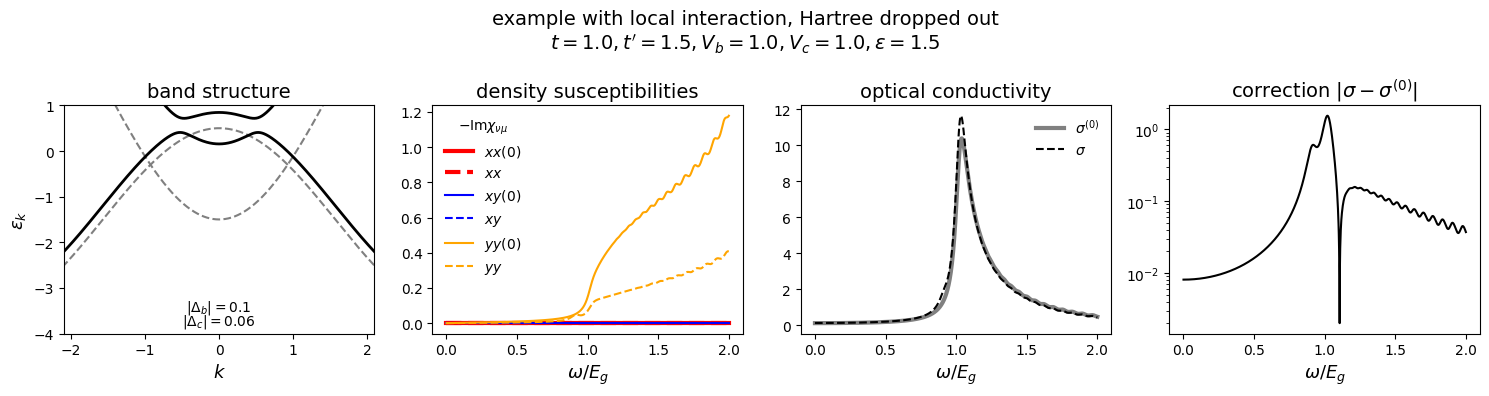

In [433]:


fig, ax = plt.subplots(ncols=4, figsize=(15,4))

ax[0].plot(m.K, 2*t*np.cos(m.K) - epsilon, ls='dashed', color='grey')
ax[0].plot(m.K, -2*t_*np.cos(m.K) + epsilon_, ls='dashed', color='grey')
ax[0].plot(m.K, m.energije[0], color='black', lw=2)
ax[0].plot(m.K, m.energije[1], color='black', lw=2)

gap = np.min(m.energije[1]) - np.max(m.energije[0])
rob = np.max(m.energije[1]) - np.min(m.energije[0])
rob2 = np.min(m.energije[1]) - np.min(m.energije[0])
gap, rob, rob2


omegas = np.linspace(1e-6,2*gap,1001)
Gamma = 0.006

chi0, chi = chi_rho_rho(m.K, phys_parameters, m.vecs, m.energije, m.fs, omegas, Gamma, include_hartree)

m.mu = 0.5*(np.min(m.energije[1]) + np.max(m.energije[0]))
epsilons = omegas
T = 0.1 * gap
jj, djj, chi_rh_rh, chi_rh_j = chi_j_j(m.K, phys_parameters, m.vecs, m.energije, m.fs, omegas, Gamma, include_hartree)

ax[1].plot(omegas/gap,-chi0[0,0].imag, color='red', lw=3, label=r'$xx(0)$')
ax[1].plot(omegas/gap,-chi[0,0].imag, color='red', ls='dashed', lw=3, label=r'$xx$')

ax[1].plot(omegas/gap, -chi0[0,1].imag, color='blue', label=r'$xy(0)$')
ax[1].plot(omegas/gap, -chi[0,1].imag, color='blue', ls='dashed', label=r'$xy$')

ax[1].plot(omegas/gap,-chi0[1,1].imag, color='orange', label=r'$yy(0)$')
ax[1].plot(omegas/gap,-chi[1,1].imag, color='orange', ls='dashed', label=r'$yy$')

ax[1].legend(frameon=False).set_title(r'$-\text{Im} \chi_{\nu\mu}$')

ax[2].plot(omegas/gap,  -jj.imag / omegas, label=r'$\sigma^{(0)}$', color='grey', lw=3)
ax[2].plot(omegas/gap,  -(jj + djj).imag / omegas, label=r'$\sigma$', color='black', ls='dashed')
ax[3].plot(omegas/gap, np.abs(-djj.imag / omegas), color='black')
ax[2].legend(frameon=False)
for j in range(3):
    ax[1+j].set_xlabel(r'$\omega/E_g$', fontsize=13)
ax[0].set_xlim(-2.1,2.1)
ax[0].set_xlabel(r'$k$', fontsize=13)
ax[0].set_ylabel(r'$\varepsilon_k$', fontsize=13)
ax[0].set_ylim(-4,1)
ax[0].set_title(r'band structure', fontsize=14)
ax[1].set_title(r'density susceptibilities', fontsize=14)
#ax[1].text(0.7, 1.2, 'x: amplitude, y: phase', ha='center', fontsize=8)
ax[2].set_title(r'optical conductivity', fontsize=14)
#ax[2].text(0.0, 15, r'$\sigma(\omega) = \frac{1}{\omega} \text{Im} \chi_{jj}(\omega)$', fontsize=12)
ax[3].set_title(r'correction $|\sigma - \sigma^{(0)}|$', fontsize=14)
ax[3].set_yscale('log')

ax[0].text(0, -3.5, rf'$|\Delta_b| = {np.round(np.abs(m.delta_b), 2)}$', ha='center')
ax[0].text(0, -3.8, rf'$|\Delta_c| = {np.round(np.abs(m.delta_c), 2)}$', ha='center')

fig.suptitle('example with local interaction, Hartree dropped out' + '\n' + rf"$t={t}, t'={t_}, V_b={Vb}, V_c={Vc}, \varepsilon={epsilon}$", fontsize=14)

plt.tight_layout()
#plt.savefig('example_local.png')


-4.0


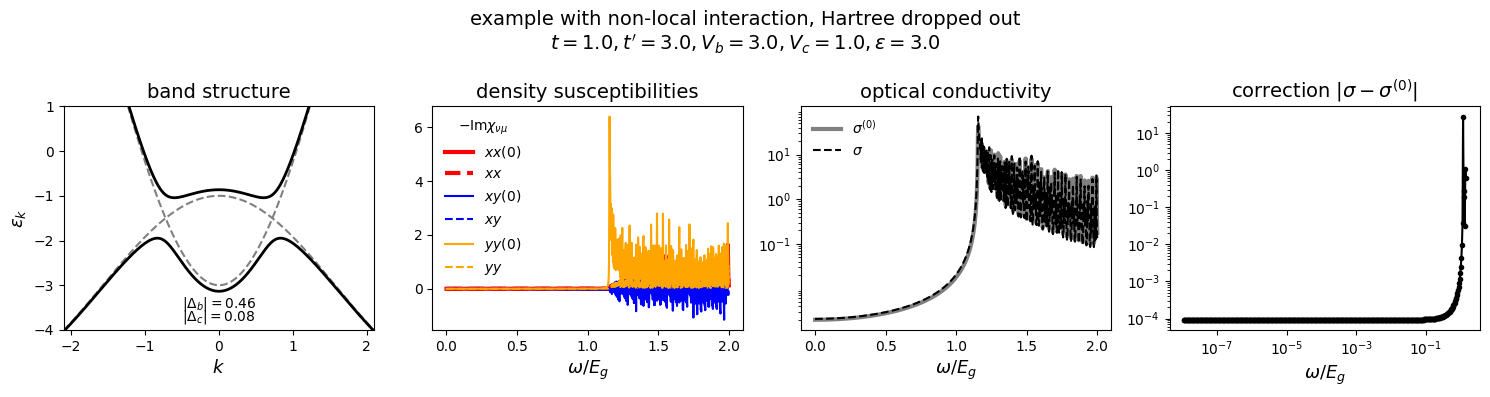

In [4]:
Nk = 1300
a = 1.
b = 0.#5

t12 = 0.
delta = 0.

t = 1.
t_ = 3.
Vc = 1.
Vb = 3.
gap = -1.5
epsilon = 3.
epsilon_ = 3.

#epsilon = 0.5*(gap + 2*t_ + 2*t)
#epsilon_ = epsilon
gap0 = epsilon_ - 2*t_ - (epsilon - 2*t)
print(gap0)

phys_parameters = [b, t, t_, t12, epsilon, epsilon_, Vb, Vc, delta]

mu0 = 0.
include_hartree = False
m = model(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree)
m.GS()

fig, ax = plt.subplots(ncols=4, figsize=(15,4))

ax[0].plot(m.K, 2*t*np.cos(m.K) - epsilon, ls='dashed', color='grey')
ax[0].plot(m.K, -2*t_*np.cos(m.K) + epsilon_, ls='dashed', color='grey')
ax[0].plot(m.K, m.energije[0], color='black', lw=2)
ax[0].plot(m.K, m.energije[1], color='black', lw=2)

gap = np.min(m.energije[1]) - np.max(m.energije[0])
rob = np.max(m.energije[1]) - np.min(m.energije[0])
rob2 = np.min(m.energije[1]) - np.min(m.energije[0])
gap, rob, rob2
mu = 0.5 * (np.min(m.energije[1]) + np.max(m.energije[0]))
m.mu = mu
T = gap / 10


fs = np.zeros((2, 2, m.Nk))
T = gap/10
fs[0,0] = 1/(1 + np.exp((m.energije[0,:] - m.mu)/T))
fs[1,1] = 1/(1 + np.exp((m.energije[1,:] - m.mu)/T))

omegas = np.linspace(1e-6,2*gap,1001)
Gamma = 0.0005

chi0, chi = chi_rho_rho(m.K, phys_parameters, m.vecs, m.energije, fs, omegas, Gamma, include_hartree)
jj, djj, chi_rh_rh, chi_rh_j = chi_j_j(m.K, phys_parameters, m.vecs, m.energije, fs, omegas, Gamma, include_hartree)


ax[1].plot(omegas/gap,-chi0[0,0].imag, color='red', lw=3, label=r'$xx(0)$')
ax[1].plot(omegas/gap,-chi[0,0].imag, color='red', ls='dashed', lw=3, label=r'$xx$')

ax[1].plot(omegas/gap, -chi0[0,1].imag, color='blue', label=r'$xy(0)$')
ax[1].plot(omegas/gap, -chi[0,1].imag, color='blue', ls='dashed', label=r'$xy$')

ax[1].plot(omegas/gap,-chi0[1,1].imag, color='orange', label=r'$yy(0)$')
ax[1].plot(omegas/gap,-chi[1,1].imag, color='orange', ls='dashed', label=r'$yy$')

ax[1].legend(frameon=False).set_title(r'$-\text{Im} \chi_{\nu\mu}$')

ax[2].plot(omegas/gap,  -jj.imag / omegas, label=r'$\sigma^{(0)}$', color='grey', lw=3)
ax[2].plot(omegas/gap,  -(jj + djj).imag / omegas, label=r'$\sigma$', color='black', ls='dashed')

omegas2 = np.logspace(-8,0.1,501)
jj, djj, chi_rh_rh, chi_rh_j = chi_j_j(m.K, phys_parameters, m.vecs, m.energije, fs, omegas2, Gamma, include_hartree)
ax[3].plot(omegas2/gap, np.abs(-djj.imag / omegas2), '.-', color='black')
corr = np.mean((-djj.imag / omegas2)[:10])
ax[3].set_xscale('log')
ax[2].legend(frameon=False)
for j in range(3):
    ax[1+j].set_xlabel(r'$\omega/E_g$', fontsize=13)
ax[0].set_xlim(-2.1,2.1)
ax[0].set_xlabel(r'$k$', fontsize=13)
ax[0].set_ylabel(r'$\varepsilon_k$', fontsize=13)
ax[0].set_ylim(-4,1)
ax[0].set_title(r'band structure', fontsize=14)
ax[1].set_title(r'density susceptibilities', fontsize=14)
#ax[1].text(0.7, 1.2, 'x: amplitude, y: phase', ha='center', fontsize=8)
ax[2].set_title(r'optical conductivity', fontsize=14)
#ax[2].text(0.0, 15, r'$\sigma(\omega) = \frac{1}{\omega} \text{Im} \chi_{jj}(\omega)$', fontsize=12)
ax[3].set_title(r'correction $|\sigma - \sigma^{(0)}|$', fontsize=14)
ax[3].set_yscale('log')

ax[0].text(0, -3.5, rf'$|\Delta_b| = {np.round(np.abs(m.delta_b), 2)}$', ha='center')
ax[0].text(0, -3.8, rf'$|\Delta_c| = {np.round(np.abs(m.delta_c), 2)}$', ha='center')

ax[2].set_yscale('log')

ax[2].set_yticks([1e-1,1e0,1e1])

fig.suptitle('example with non-local interaction, Hartree dropped out' + '\n' + rf"$t={t}, t'={t_}, V_b={Vb}, V_c={Vc}, \varepsilon={epsilon}$", fontsize=14)
plt.tight_layout()
plt.savefig('example_nonlocal.png')


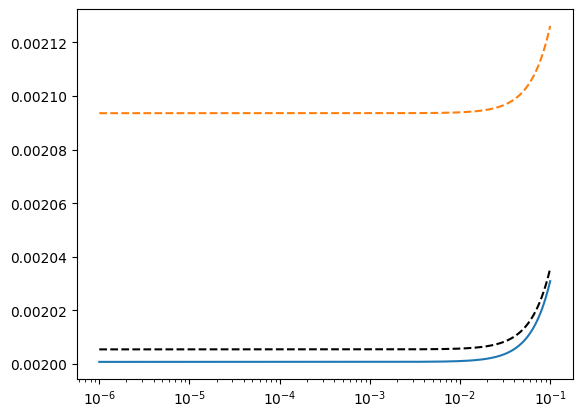

In [5]:
tok = j_tok(m.K, phys_parameters, m.mu)
tok_tilde = np.einsum('jix,jlx,lmx -> imx', m.vecs.conj(), tok, m.vecs)

delta_b, delta_c = Delta(m.K, m.rho, Vb, Vc)

dfock_dk = np.zeros(tok.shape, dtype=np.complex128)
# Fock term:
delta_k = -1j * delta_c * np.exp(-1j*m.K)
dfock_dk[0,1,:] += delta_k
dfock_dk[1,0,:] += delta_k.conj()
dfock_dk_tilde = np.einsum('jix,jlx,lmx -> imx', m.vecs.conj(), dfock_dk, m.vecs)


omegas = np.linspace(1e-6,0.1,301)

jj, djj, chi_rh_rh, chi_rh_j = chi_j_j(m.K, phys_parameters, m.vecs, m.energije, fs, omegas, Gamma, include_hartree)
chi_j_j2 = chi_Kubo_omegas(m.K, tok_tilde, tok_tilde + dfock_dk_tilde, omegas, m.energije, fs, Gamma)
plt.plot(omegas, -jj.imag/omegas)
plt.plot(omegas, -(jj + djj).imag/omegas, ls='dashed')
plt.plot(omegas, -(chi_j_j2.imag)/omegas, ls='dashed', color='black')
plt.xscale('log')




0.20286499590682894

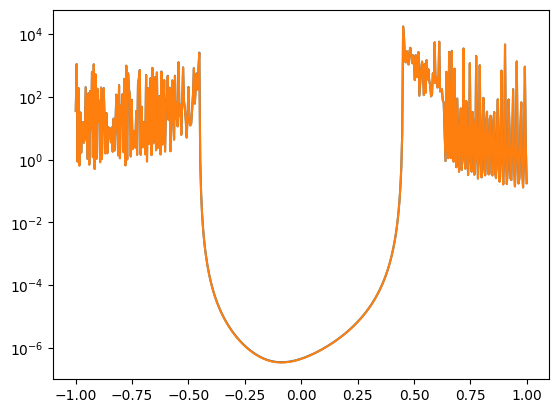

In [6]:
mu = 0.5 * (np.min(m.energije[1]) + np.max(m.energije[0]))
m.mu = mu
tok = j_tok(m.K, phys_parameters, m.mu)
tok_tilde = np.einsum('jix,jlx,lmx -> imx', m.vecs.conj(), tok, m.vecs)

delta_b, delta_c = Delta(m.K, m.rho, Vb, Vc)

dfock_dk = np.zeros(tok.shape, dtype=np.complex128)
# Fock term:
delta_k = -1j * delta_c * np.exp(-1j*m.K) * (0 - b + 1)
dfock_dk[0,1,:] += delta_k
dfock_dk[1,0,:] += delta_k.conj()
dfock_dk_tilde = np.einsum('jix,jlx,lmx -> imx', m.vecs.conj(), dfock_dk, m.vecs)


T = gap/10

omegas = np.linspace(-1,1,501)
A = Spektralka(omegas, m.mu, m.energije, Gamma)
phi = phi_Kubo(m.K, tok, tok, A, omegas, )
cond1 = -np.sum(phi * fd_1(omegas, T)).real * (omegas[1] - omegas[0])

plt.plot(omegas, phi.real)
phi = phi_Kubo(m.K, tok, tok + dfock_dk_tilde, A, omegas, )
plt.plot(omegas, phi.real)

cond2 = -np.sum(phi * fd_1(omegas, T)).real * (omegas[1] - omegas[0])
plt.yscale('log')

cond1 - cond2

In [156]:
Nk = 200
a = 1.
b = 0.#5

t12 = 0.
delta = 0.

t = 1.
t_ = 1.
Vc = 0.
Vb = 3.
gap = -2.5
epsilon = -0.5
epsilon_ = -2.45

epsilon = 0.5*(gap + 2*t_ + 2*t)
epsilon_ = epsilon
#gap0 = epsilon_ - 2*t_ - (epsilon - 2*t)

phys_parameters = [b, t, t_, t12, epsilon, epsilon_, Vb, Vc, delta]

mu0 = 0.
include_hartree = True
m = model(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree)
m.GS()

rhos, thetas = rho_operators(m.K, phys_parameters, include_hartree)


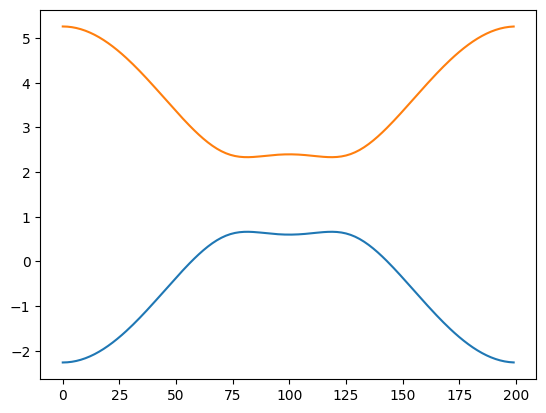

In [157]:
plt.plot(m.energije[0])
plt.plot(m.energije[1])

In [151]:

sigma_x = np.array([[0,1],[1,0]])
sigma_y = np.array([[0,-1j],[1j,0]])
sigma_z = np.diag([1,-1])
sigma_0 = np.eye(2)
sigmas = np.zeros((4, 2, 2), dtype=np.complex128)
sigmas[0] = sigma_0
sigmas[1] = sigma_x
sigmas[2] = sigma_y
sigmas[3] = sigma_z


-4.0


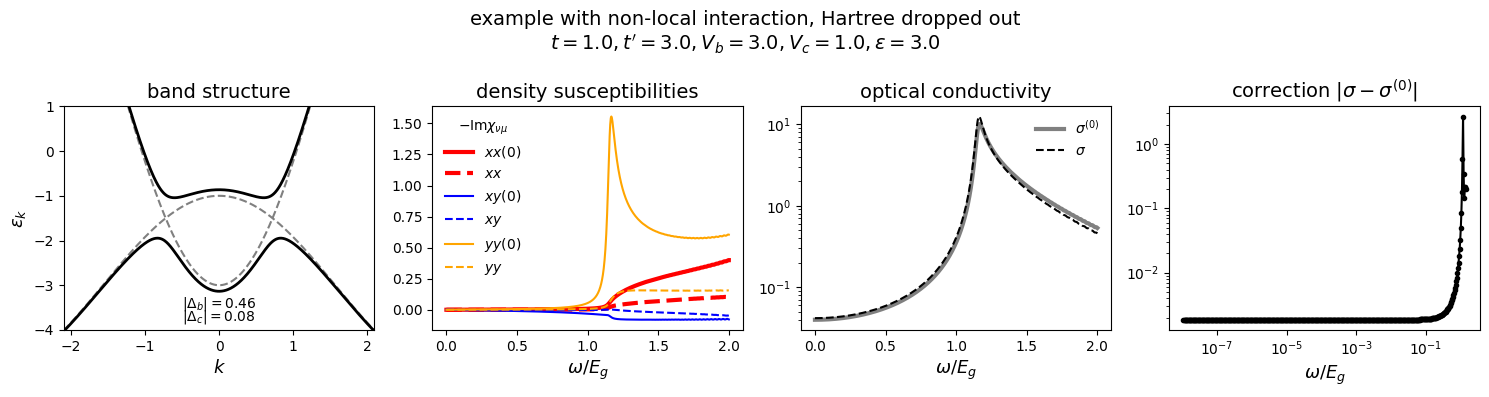

In [110]:
Nk = 1300
a = 1.
b = 0.#5

t12 = 0.
delta = 0.

t = 1.
t_ = 3.
Vc = 1.
Vb = 3.
gap = -1.5
epsilon = 3.
epsilon_ = 3.

#epsilon = 0.5*(gap + 2*t_ + 2*t)
#epsilon_ = epsilon
gap0 = epsilon_ - 2*t_ - (epsilon - 2*t)
print(gap0)

phys_parameters = [b, t, t_, t12, epsilon, epsilon_, Vb, Vc, delta]

mu0 = 0.
include_hartree = False
m = model(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree)
m.GS()

fig, ax = plt.subplots(ncols=4, figsize=(15,4))

ax[0].plot(m.K, 2*t*np.cos(m.K) - epsilon, ls='dashed', color='grey')
ax[0].plot(m.K, -2*t_*np.cos(m.K) + epsilon_, ls='dashed', color='grey')
ax[0].plot(m.K, m.energije[0], color='black', lw=2)
ax[0].plot(m.K, m.energije[1], color='black', lw=2)

gap = np.min(m.energije[1]) - np.max(m.energije[0])
rob = np.max(m.energije[1]) - np.min(m.energije[0])
rob2 = np.min(m.energije[1]) - np.min(m.energije[0])
gap, rob, rob2
mu = 0.5 * (np.min(m.energije[1]) + np.max(m.energije[0]))
m.mu = mu
T = gap / 10


fs = np.zeros((2, 2, m.Nk))
T = gap/10
fs[0,0] = 1/(1 + np.exp((m.energije[0,:] - m.mu)/T))
fs[1,1] = 1/(1 + np.exp((m.energije[1,:] - m.mu)/T))

omegas = np.linspace(1e-6,2*gap,1001)
Gamma = 0.01

chi0, chi = chi_rho_rho(m.K, phys_parameters, m.vecs, m.energije, fs, omegas, Gamma, include_hartree)
jj, djj, chi_rh_rh, chi_rh_j = chi_j_j(m.K, phys_parameters, m.vecs, m.energije, fs, omegas, Gamma, include_hartree)


ax[1].plot(omegas/gap,-chi0[0,0].imag, color='red', lw=3, label=r'$xx(0)$')
ax[1].plot(omegas/gap,-chi[0,0].imag, color='red', ls='dashed', lw=3, label=r'$xx$')

ax[1].plot(omegas/gap, -chi0[0,1].imag, color='blue', label=r'$xy(0)$')
ax[1].plot(omegas/gap, -chi[0,1].imag, color='blue', ls='dashed', label=r'$xy$')

ax[1].plot(omegas/gap,-chi0[1,1].imag, color='orange', label=r'$yy(0)$')
ax[1].plot(omegas/gap,-chi[1,1].imag, color='orange', ls='dashed', label=r'$yy$')

ax[1].legend(frameon=False).set_title(r'$-\text{Im} \chi_{\nu\mu}$')

ax[2].plot(omegas/gap,  -jj.imag / omegas, label=r'$\sigma^{(0)}$', color='grey', lw=3)
ax[2].plot(omegas/gap,  -(jj + djj).imag / omegas, label=r'$\sigma$', color='black', ls='dashed')

omegas2 = np.logspace(-8,0.1,501)
jj, djj, chi_rh_rh, chi_rh_j = chi_j_j(m.K, phys_parameters, m.vecs, m.energije, fs, omegas2, Gamma, include_hartree)
ax[3].plot(omegas2/gap, np.abs(-djj.imag / omegas2), '.-', color='black')
corr = np.mean((-djj.imag / omegas2)[:10])
ax[3].set_xscale('log')
ax[2].legend(frameon=False)
for j in range(3):
    ax[1+j].set_xlabel(r'$\omega/E_g$', fontsize=13)
ax[0].set_xlim(-2.1,2.1)
ax[0].set_xlabel(r'$k$', fontsize=13)
ax[0].set_ylabel(r'$\varepsilon_k$', fontsize=13)
ax[0].set_ylim(-4,1)
ax[0].set_title(r'band structure', fontsize=14)
ax[1].set_title(r'density susceptibilities', fontsize=14)
#ax[1].text(0.7, 1.2, 'x: amplitude, y: phase', ha='center', fontsize=8)
ax[2].set_title(r'optical conductivity', fontsize=14)
#ax[2].text(0.0, 15, r'$\sigma(\omega) = \frac{1}{\omega} \text{Im} \chi_{jj}(\omega)$', fontsize=12)
ax[3].set_title(r'correction $|\sigma - \sigma^{(0)}|$', fontsize=14)
ax[3].set_yscale('log')

ax[0].text(0, -3.5, rf'$|\Delta_b| = {np.round(np.abs(m.delta_b), 2)}$', ha='center')
ax[0].text(0, -3.8, rf'$|\Delta_c| = {np.round(np.abs(m.delta_c), 2)}$', ha='center')

ax[2].set_yscale('log')

ax[2].set_yticks([1e-1,1e0,1e1])

fig.suptitle('example with non-local interaction, Hartree dropped out' + '\n' + rf"$t={t}, t'={t_}, V_b={Vb}, V_c={Vc}, \varepsilon={epsilon}$", fontsize=14)
plt.tight_layout()
plt.savefig('example_nonlocal.png')


In [119]:
dHk2_dk2 = np.zeros((2, 2, m.Nk), dtype=np.complex128)
b, t, t_, t12, epsilon, epsilon_, Vb, Vc, delta = phys_parameters
dHk2_dk2[0,0,:] = -2*t*np.cos(m.K)
dHk2_dk2[1,1,:] = 2*t_*np.cos(m.K)
delta_b, delta_c = Delta(m.K, m.rho, Vb, Vc)
dHk2_dk2[0,1,:] += - delta_c * np.exp(-1j*m.K)
dHk2_dk2[1,0,:] += - delta_c * np.exp(-1j*m.K)
D = 0.
for n in range(m.Nk):
    D += np.trace(m.rho[:,:,n] @ dHk2_dk2[:,:,n])

(0.0, 3.0)

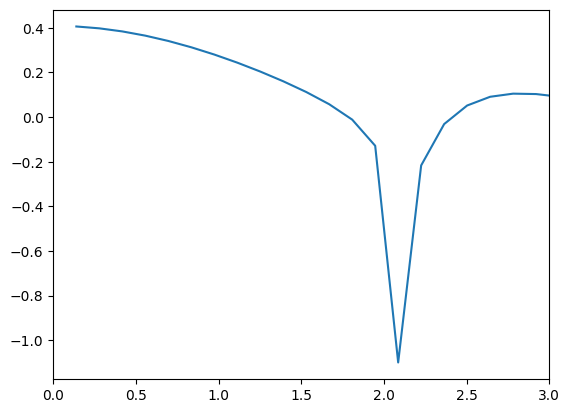

In [118]:
window = np.exp(-Gamma * ts)

signal = np.fft.fft((rho_expvals - rho_expvals[0]) * window * dt)
omega  = 2*np.pi*np.fft.fftfreq(len(ts), d=dt)

pos = omega > 0
omega = omega[pos]
signal = signal[pos]

# NO omega+iGamma here
sigma = signal / (1j * omega) - D/(1j * omega)

plt.plot(omega/gap, np.real(sigma))
plt.xlim(0,3)

In [ ]:
window = np.exp(-Gamma * ts)

signal = np.fft.fft((rho_expvals - rho_expvals[0]) * window * dt)
omega  = 2*np.pi*np.fft.fftfreq(len(ts), d=dt)

pos = omega > 0
omega = omega[pos]
signal = signal[pos]

# NO omega+iGamma here
sigma = signal / (1j * omega) - D/(1j * omega)

plt.plot(omega/gap, np.real(sigma))
plt.xlim(0,3)

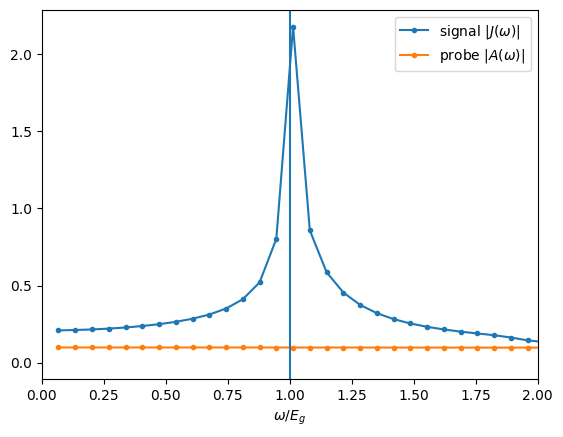

In [36]:
plt.plot(omega/gap, np.abs(signal), '.-', label=r'signal $|J(\omega)|$')


plt.plot(omega/gap, np.abs(probe)*100, '.-', label=r'probe $|A(\omega)|$')
plt.xlabel(r'$\omega/E_g$')
plt.xlim(0,2)
plt.legend()
plt.axvline(1)

In [183]:

omegas = np.linspace(0,3*gap,1001)
Gamma = 0.006

res = chi_rho_rho(m.K, phys_parameters, m.vecs, m.energije, m.fs, omegas, Gamma, include_hartree)

jj, djj = chi_j_j(m.K, phys_parameters, m.vecs, m.energije, m.fs, omegas, Gamma, include_hartree)


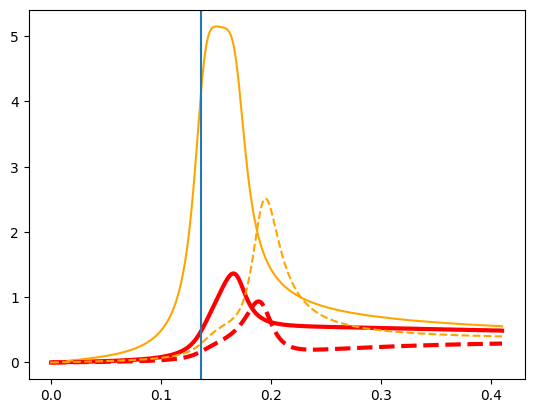

In [184]:
plt.plot(omegas,-res[0][0,0].imag, color='red', lw=3)
plt.plot(omegas,-res[0][1,1].imag, color='orange')

plt.plot(omegas,-res[1][0,0].imag, color='red', ls='dashed', lw=3)
plt.plot(omegas,-res[1][1,1].imag, color='orange', ls='dashed')


plt.axvline(gap)


C:\Users\anast\AppData\Local\Temp\ipykernel_54448\3067689767.py:1: RuntimeWarning: divide by zero encountered in divide
  plt.plot(omegas,  -jj.imag / omegas / np.pi)
C:\Users\anast\AppData\Local\Temp\ipykernel_54448\3067689767.py:2: RuntimeWarning: divide by zero encountered in divide
  plt.plot(omegas,  -(jj + djj[0]).imag / omegas / np.pi)


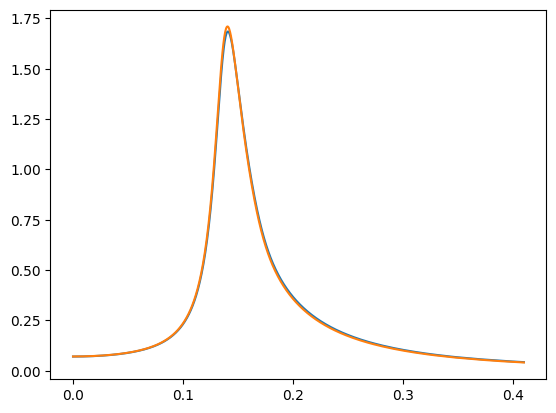

In [185]:
plt.plot(omegas,  -jj.imag / omegas / np.pi)
plt.plot(omegas,  -(jj + djj[0]).imag / omegas / np.pi)
